# Phase 1.3: Calibration Production & Fleet Expansion

This notebook implements the calibration pipeline for the sensor network. It takes the models verified in Phase 1.2, trains them on the entire available dataset, and applies the physical reference-free calibration "Drying" universally.

## Objectives
1. **Final Model Training:** Train the final Random Forest models for all nodes on 100% of their respective wind-filtered training sets using optimal hyperparameters derived in Phase 1.2.
2. **Longitudinal Application:** Apply the physical drying models to the entire 14-month continuous dataset across the sensor fleet, using the empirical activation thresholds.
3. **Regional Scaling:** Evaluate the dried Node 3 against the TH2 reference monitor to derive a regional scaling factor.
4. **Supervised Baseline Evaluation:** Compare the reference-free method against a supervised Oracle baseline to quantify methodological efficacy.

## Environment Configuration

In [1]:
import pandas as pd
import numpy as np
import os
import json
from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

PROCESSED_DIR = '../data/02_interim'
CALIBRATION_DIR = '../data/03_calibration'
CALIBRATED_MASTER_DIR = '../data/04_calibrated_master'
POOL_FILE = os.path.join(CALIBRATION_DIR, 'pools/calibration_training_pools.csv')
MASTER_1MIN = os.path.join(PROCESSED_DIR, 'master_low_cost_1min.csv')
MASTER_15MIN = os.path.join(PROCESSED_DIR, 'master_combined_15min.csv')

os.makedirs(CALIBRATED_MASTER_DIR, exist_ok=True)

def get_mbe(y_true, y_pred):
    return np.mean(y_pred - y_true)


## 1. Data Loading & Feature Engineering

The 1-minute longitudinal dataset and the 'Training Pool' are loaded. Physical proxy variables derived from Köhler theory (and Absolute Humidity) are computed to allow the model to capture non-linear aerosol swelling dynamics, as well as interaction terms between the features.

In [2]:
print('Loading data...')
df_pool = pd.read_csv(POOL_FILE)
df_pool['timestamp_utc'] = pd.to_datetime(df_pool['timestamp_utc'], utc=True)

df_1m = pd.read_csv(MASTER_1MIN)
df_1m['timestamp_utc'] = pd.to_datetime(df_1m['timestamp_utc'], utc=True)

def get_features(df, out_col, t_col_out, h_col_out):
    df_feat = pd.DataFrame({
        'timestamp_utc': df['timestamp_utc'],
        'pm25_raw': df[out_col],
        'temp': df[t_col_out],
        'humi': df[h_col_out]
    })
    rh_capped = np.clip(df_feat['humi'], 0, 99.5)
    df_feat['kohler_proxy'] = rh_capped / (100 - rh_capped)
    
    temp_c = df_feat['temp']
    es = 6.112 * np.exp((17.62 * temp_c) / (temp_c + 243.21))
    e = es * (rh_capped / 100.0)
    df_feat['abs_humidity'] = (e * 100 * 2.167) / (temp_c + 273.15)
    
    df_feat['pm_humi_int'] = df_feat['pm25_raw'] * df_feat['humi']
    df_feat['pm_temp_int'] = df_feat['pm25_raw'] * df_feat['temp']
    df_feat['pm_kohler_int'] = df_feat['pm25_raw'] * df_feat['kohler_proxy']
    
    return df_feat.replace([np.inf, -np.inf], np.nan)

print(f'Pool loaded: {len(df_pool)} rows. Longitudinal loaded: {len(df_1m)} rows.')

Loading data...


Pool loaded: 213236 rows. Longitudinal loaded: 606240 rows.


## 2. Final Model Training (Drying Logic)

Final Random Forest Regressors are trained for all operational nodes using 100% of their respective wind-filtered training sets. The optimal hyperparameters and physical thresholds derived in Phase 1.2 are loaded directly.

In [ ]:
fleet_configs = {
    'node_3': {'b_name': 'Eng Building', 'out': 'node_3_pm25', 'in': 'node_4_pm25', 'h': 'node_3_humi', 't': 'node_3_temp'},
    'node_1': {'b_name': 'Stefan Office', 'out': 'node_1_pm25', 'in': 'node_2_pm25', 'h': 'node_1_humi', 't': 'node_1_temp'},
    'node_6_Eng': {'b_name': 'Node 7 Eng', 'out': 'node_6_pm25', 'in': 'node_7_Eng_pm25', 'h': 'node_6_humi', 't': 'node_6_temp'},
    'node_6_PP': {'b_name': 'Node 7 PP', 'out': 'node_6_pm25', 'in': 'node_7_PP_pm25', 'h': 'node_6_humi', 't': 'node_6_temp'}
}

# Load optimal parameters from Phase 1.2a
with open(os.path.join(CALIBRATION_DIR, 'parameters/optimal_parameters.json'), 'r') as f:
    optimal_params = json.load(f)

rf_models = {}
r0_baselines = {}
features_cols = ['pm25_raw', 'temp', 'humi', 'abs_humidity', 'pm_humi_int', 'pm_temp_int', 'pm_kohler_int', 'kohler_proxy']

for pair_name, cfg in fleet_configs.items():
    pair_df = df_pool[df_pool['building'] == cfg['b_name']].copy()
    phys_params = optimal_params[pair_name]['phys_params']
    
    # Strict physical filters
    pair_df = pair_df[pair_df[cfg['in']] <= pair_df[cfg['out']]]
    in_humi_col = cfg['in'].replace('pm25', 'humi')
    if in_humi_col in pair_df.columns:
        pair_df = pair_df[pair_df[in_humi_col] <= 55]
        
    # Derive R0 (Dry Baseline) using configured threshold
    dry_mask = pair_df[cfg['h']] < phys_params['r0_rh']
    r0 = pair_df.loc[dry_mask, cfg['out']].median() / pair_df.loc[dry_mask, cfg['in']].median()
    r0_baselines[pair_name] = r0
    
    # Extract Features and Target Ratio
    processed = get_features(pair_df, cfg['out'], cfg['t'], cfg['h'])
    valid_mask = pair_df[cfg['in']] > 0
    processed = processed[valid_mask].copy()
    y_train = pair_df.loc[valid_mask, cfg['out']] / pair_df.loc[valid_mask, cfg['in']]
    
    # Train model using ML parameters optimized in Phase 1.2
    ml_params = optimal_params[pair_name]['ml_params']
    rf = RandomForestRegressor(**ml_params, random_state=42, n_jobs=-1)
    rf.fit(processed[features_cols], y_train)
    rf_models[pair_name] = rf
    
    print(f"{pair_name} - R0: {r0:.4f} | ML Params: {ml_params} | Training R2: {rf.score(processed[features_cols], y_train):.4f}")

node_3 - R0: 1.7397 | ML Params: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200} | Training R2: 0.4274


node_1 - R0: 2.6428 | ML Params: {'max_depth': 5, 'max_features': 1.0, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200} | Training R2: 0.6885


node_6_Eng - R0: 3.5135 | ML Params: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200} | Training R2: 0.3803


node_6_PP - R0: 2.1756 | ML Params: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200} | Training R2: 0.3035


## 3. Stage 1 Application: Fleet Longitudinal Drying

The learned 'Drying Rules' are applied to the entire 14-month continuous dataset. A smooth Continuous Blending Gate (Logistic Sigmoid Function) ensures the physical correction targets periods affected by higher humidity interference without disrupting baseline (lower humidity) operational states.

In [4]:
for pair_name, cfg in fleet_configs.items():
    phys_params = optimal_params[pair_name]['phys_params']
    midpoint = phys_params['midpoint']
    steepness = phys_params['steepness']
    
    # Extract longitduinal features
    X_full = get_features(df_1m, cfg['out'], cfg['t'], cfg['h'])
    X_full = X_full.dropna(subset=features_cols)
    
    # Predict hygroscopic ratio
    ratio_pred = rf_models[pair_name].predict(X_full[features_cols])
    growth_factor = np.maximum(ratio_pred / r0_baselines[pair_name], 1.0)
    
    # Apply continuous Sigmoid blending gate
    weight = 1 / (1 + np.exp(-steepness * (X_full['humi'] - midpoint)))
    dry_values = X_full['pm25_raw'] / (1.0 + weight * (growth_factor - 1.0))
    
    df_1m.loc[X_full.index, f'{pair_name}_dry'] = dry_values

# Merges segmented deployment periods into continuous timeline
df_1m['node_6_dry'] = np.nan
mask_eng = df_1m['timestamp_utc'] < '2025-06-16'
mask_pp = df_1m['timestamp_utc'] > '2025-06-19'
df_1m.loc[mask_eng, 'node_6_dry'] = df_1m.loc[mask_eng, 'node_6_Eng_dry']
df_1m.loc[mask_pp, 'node_6_dry'] = df_1m.loc[mask_pp, 'node_6_PP_dry']

# Drop the temporary split columns
df_1m = df_1m.drop(columns=['node_6_Eng_dry', 'node_6_PP_dry'])

print("Longitudinal Fleet Drying Complete. Node 6 consolidated.")

Longitudinal Fleet Drying Complete. Node 6 consolidated.


## 4. Stage 2: Theoretical Regional Scaling Demonstration

The physically 'dried' signals consistently under-report compared to roadside reference monitors due to factory hardware baseline calibration variations. 

To illustrate this bias, we derive a scaling factor from Node 3 against TH2. However, to preserve the strict **reference-free** integrity of this methodology, this scaler is *not* applied to the broader fleet or exported. It is strictly used here to demonstrate the theoretical upper bound if baseline hardware offsets were corrected.

In [5]:
# Resample Node 3 to 15-min for scaling derivation against TH2
df_3_15m = df_1m.set_index('timestamp_utc')[['node_3_pm25', 'node_3_dry']].resample('15min').mean().reset_index()
df_ref = pd.read_csv(MASTER_15MIN)[['timestamp_utc', 'th2_mer_pm25']]
df_ref['timestamp_utc'] = pd.to_datetime(df_ref['timestamp_utc'], utc=True)

eval_df = pd.merge(df_3_15m, df_ref, on='timestamp_utc').dropna()

lr = LinearRegression().fit(eval_df[['node_3_dry']], eval_df['th2_mer_pm25'])
m, c = lr.coef_[0], lr.intercept_
print(f'Theoretical Regional Scaling Derived from Node 3: Slope={m:.4f}, Intercept={c:.4f}')

# Calculate theoretical scaled values ONLY for Node 3 to illustrate the bias in evaluation.
# We explicitly do NOT apply this to the fleet to preserve reference-free integrity.
df_1m['Node_3_scaled_theoretical'] = m * df_1m['node_3_dry'] + c

print("Theoretical scaling calculated for demonstration. Fleet remains strictly reference-free.")

Theoretical Regional Scaling Derived from Node 3: Slope=0.8380, Intercept=3.0838
Theoretical scaling calculated for demonstration. Fleet remains strictly reference-free.


## 5. Stage 3: Pair B Empirical Proof & Supervised Baseline Evaluation

Node 3 is evaluated against the co-located TH2 reference monitor to verify methodology success using EPA-aligned performance metrics. 
To understand performance relative to the theoretical ceiling, a Supervised Baseline model (trained *directly* on TH2 data) is provided for absolute comparison. This isolates how close the reference-free indoor methodology approaches a supervised methodology.

In [ ]:
df_final_1h = df_1m.set_index('timestamp_utc')[['node_3_pm25', 'node_3_dry', 'Node_3_scaled_theoretical']].resample('1h').mean().reset_index()
df_ref_1h = df_ref.set_index('timestamp_utc')[['th2_mer_pm25']].resample('1h').mean().reset_index()
df_eval_1h = pd.merge(df_final_1h, df_ref_1h, on='timestamp_utc').dropna()

results_1h = []
for col, name in [('node_3_pm25', 'Raw'), ('node_3_dry', 'Dried (Reference-Free)'), ('Node_3_scaled_theoretical', 'Scaled (Theoretical Demonstration)')]:
    y_true, y_pred = df_eval_1h['th2_mer_pm25'], df_eval_1h[col]
    m_eval, c_eval = np.polyfit(y_true, y_pred, 1)
    res = y_pred - y_true
    results_1h.append({
        'Stage': name,
        'Bias (Slope)': m_eval,
        'Bias (Intercept)': c_eval,
        'Linearity (R2)': r2_score(y_true, y_pred),
        'Error (RMSE)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'Error (NRMSE)': np.sqrt(mean_squared_error(y_true, y_pred)) / y_true.mean()
    })

# --- Supervised Baseline (Oracle) Training & Evaluation ---
# The Supervised Baseline uses the exact same physical inputs, but uses TH2 as the target.
from sklearn.model_selection import cross_val_predict, KFold
oracle_df = pd.merge(df_1m, df_ref, on='timestamp_utc').dropna(subset=['th2_mer_pm25', 'node_3_pm25'])
X_oracle = get_features(oracle_df, 'node_3_pm25', 'node_3_temp', 'node_3_humi')
X_oracle = X_oracle.dropna(subset=features_cols)
y_oracle = oracle_df.loc[X_oracle.index, 'th2_mer_pm25'] / oracle_df.loc[X_oracle.index, 'node_3_pm25']

# Using 5-Fold Cross Validation with Node 3's identical architecture
ml_params_oracle = optimal_params['node_3']['ml_params']
oracle_rf = RandomForestRegressor(**ml_params_oracle, random_state=42, n_jobs=-1)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
ratio_pred_oracle = cross_val_predict(oracle_rf, X_oracle[features_cols], y_oracle, cv=kf, n_jobs=-1)

oracle_df.loc[X_oracle.index, 'oracle_dry'] = oracle_df.loc[X_oracle.index, 'node_3_pm25'] * ratio_pred_oracle

oracle_1h = oracle_df.set_index('timestamp_utc')[['oracle_dry', 'th2_mer_pm25']].resample('1h').mean().dropna()
y_true_o, y_pred_o = oracle_1h['th2_mer_pm25'], oracle_1h['oracle_dry']
m_o, c_o = np.polyfit(y_true_o, y_pred_o, 1)
res_o = y_pred_o - y_true_o

results_1h.append({
    'Stage': 'Oracle (Supervised)',
    'Bias (Slope)': m_o,
    'Bias (Intercept)': c_o,
    'Linearity (R2)': r2_score(y_true_o, y_pred_o),
    'Error (RMSE)': np.sqrt(mean_squared_error(y_true_o, y_pred_o)),
    'Error (NRMSE)': np.sqrt(mean_squared_error(y_true_o, y_pred_o)) / y_true_o.mean()
})

print('\n--- Final 1-Hour Regulatory Resolution Evaluation ---')
display(pd.DataFrame(results_1h))


--- Final 1-Hour Regulatory Resolution Evaluation ---


,Stage,Bias (Slope),Bias (Intercept),Linearity (R2),Error (RMSE),Error (NRMSE)
0,Raw,1.096992,-1.882697,0.542225,4.590664,0.537995
1,Dried (Reference-Free),0.853020,-0.773442,0.611515,4.228987,0.495609
2,Scaled (Theoretical Demonstration),0.714850,2.435628,0.723751,3.566148,0.417929
3,Oracle (Supervised),0.765559,2.075539,0.755628,3.354091,0.393077


In [7]:
# Create 24-Hour Averages
df_final_24h = df_1m.set_index('timestamp_utc')[['node_3_pm25', 'node_3_dry', 'Node_3_scaled_theoretical']].resample('24h').mean().reset_index()
df_ref_24h = df_ref.set_index('timestamp_utc')[['th2_mer_pm25']].resample('24h').mean().reset_index()
df_eval_24h = pd.merge(df_final_24h, df_ref_24h, on='timestamp_utc').dropna()

# Get 24h Oracle
oracle_24h = oracle_df.set_index('timestamp_utc')[['oracle_dry', 'th2_mer_pm25']].resample('24h').mean().dropna()

results_24h = []

for stage, col in zip(['Raw', 'Dried (Reference-Free)', 'Scaled (Theoretical Demonstration)'], 
                      ['node_3_pm25', 'node_3_dry', 'Node_3_scaled_theoretical']): 
    y_true = df_eval_24h['th2_mer_pm25']
    y_pred = df_eval_24h[col]
    
    m_eval, c_eval = np.polyfit(y_true, y_pred, 1)
    res = y_pred - y_true
    
    results_24h.append({
        'Stage': stage,
        'Bias (Slope)': m_eval,
        'Bias (Intercept)': c_eval,
        'Linearity (R2)': r2_score(y_true, y_pred),
        'Error (RMSE)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'Error (NRMSE)': np.sqrt(mean_squared_error(y_true, y_pred)) / y_true.mean()
    })

# Add 24h Oracle
y_true_o = oracle_24h['th2_mer_pm25']
y_pred_o = oracle_24h['oracle_dry']
m_o, c_o = np.polyfit(y_true_o, y_pred_o, 1)
res_o = y_pred_o - y_true_o

results_24h.append({
    'Stage': 'Oracle (Supervised)',
    'Bias (Slope)': m_o,
    'Bias (Intercept)': c_o,
    'Linearity (R2)': r2_score(y_true_o, y_pred_o),
    'Error (RMSE)': np.sqrt(mean_squared_error(y_true_o, y_pred_o)),
    'Error (NRMSE)': np.sqrt(mean_squared_error(y_true_o, y_pred_o)) / y_true_o.mean()
})

print('\n--- Final 24-Hour Regulatory Resolution Evaluation ---')
display(pd.DataFrame(results_24h))



--- Final 24-Hour Regulatory Resolution Evaluation ---


,Stage,Bias (Slope),Bias (Intercept),Linearity (R2),Error (RMSE),Error (NRMSE)
0,Raw,1.275707,-3.542926,0.613735,3.133457,0.371313
1,Dried (Reference-Free),1.004938,-2.191121,0.662154,2.930492,0.347262
2,Scaled (Theoretical Demonstration),0.842161,1.247580,0.865206,1.851044,0.219348
3,Oracle (Supervised),0.917938,0.772458,0.902916,1.571520,0.186588


## 6. Export Master Calibrated Dataset

The final calibrated longitudinal dataset (containing all raw, dried, and regionally scaled variables for all nodes) is exported at both native 1-minute resolution and 15-minute averaged resolution for downstream analysis and visualisation.

In [8]:
# Export 1-minute native dataset
cols_to_export = [c for c in df_1m.columns if 'theoretical' not in c]
df_1m[cols_to_export].to_csv(os.path.join(CALIBRATED_MASTER_DIR, 'calibrated_master_1min.csv'), index=False)

# Export 15-minute aggregated dataset
df_15m = df_1m[cols_to_export].set_index('timestamp_utc').resample('15min').mean().reset_index()
df_15m.to_csv(os.path.join(CALIBRATED_MASTER_DIR, 'calibrated_master_15min.csv'), index=False)

print("Calibrated master datasets exported successfully. Theoretical derivations correctly excluded.")

Calibrated master datasets exported successfully. Theoretical derivations correctly excluded.


## 7. Visualization: Hygroscopic Error Variance (Precision)
A quantitative visualization demonstrating how the reference-free drying methodology mitigates the volatile exponential error variance (noise) caused by hygroscopic swelling at high humidity regimes, vastly improving the precision and linearity of the signal against the TH2 reference monitor.

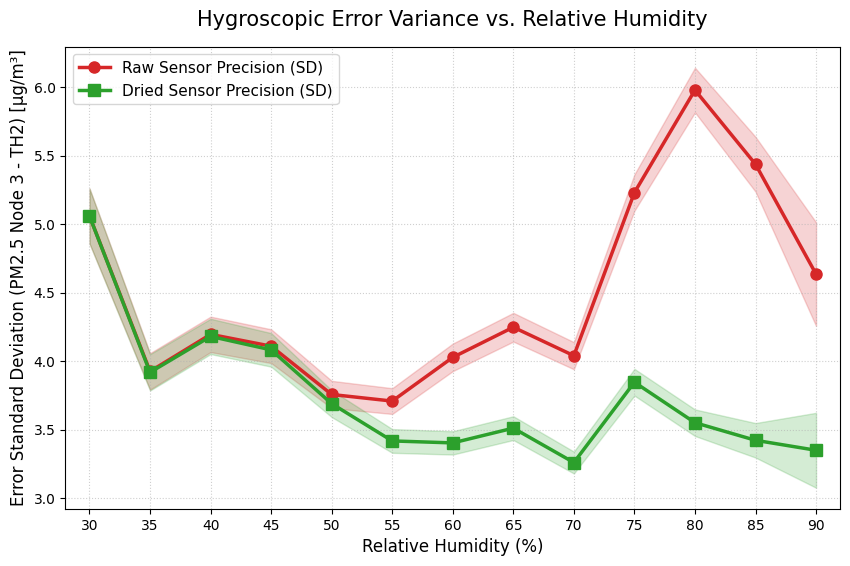

In [9]:
# Load the calibrated 1-min data and the reference 15-min data
df_cal = pd.read_csv('../data/04_calibrated_master/calibrated_master_1min.csv', parse_dates=['timestamp_utc'], index_col='timestamp_utc')
df_th2 = pd.read_csv('../data/02_interim/master_combined_15min.csv', parse_dates=['timestamp_utc'], index_col='timestamp_utc')

# Resample to 15m to match TH2
df_cal_15m = df_cal.resample('15min').mean()
df_plot = df_cal_15m.join(df_th2[['th2_mer_pm25']], how='inner').dropna(subset=['node_3_pm25', 'node_3_dry', 'th2_mer_pm25', 'node_3_humi'])

# Calculate Error from TH2
df_plot['Raw_Error'] = df_plot['node_3_pm25'] - df_plot['th2_mer_pm25']
df_plot['Dried_Error'] = df_plot['node_3_dry'] - df_plot['th2_mer_pm25']

# 1. Bin by Relative Humidity (27.5% to 100% in 5% increments)     
bins = np.arange(27.5, 103, 5)
df_plot['RH_Bin_SD'] = pd.cut(df_plot['node_3_humi'], bins=bins)
df_plot['RH_Bin_Mid_SD'] = df_plot['RH_Bin_SD'].apply(lambda x: x.mid if pd.notnull(x) else np.nan)

# 2. Calculate Standard Deviation, count, and SE of SD
sd_stats = df_plot.groupby('RH_Bin_Mid_SD')[['Raw_Error', 'Dried_Error']].agg(['std', 'count'])

# Flatten MultiIndex columns
sd_stats.columns = ['_'.join(col) for col in sd_stats.columns]
sd_stats = sd_stats.reset_index()

# Drop bins with statistically insignificant samples (< 50 points)
sd_stats = sd_stats[sd_stats['Raw_Error_count'] > 50].copy()

# Calculate Standard Error of the Standard Deviation (SE = SD / sqrt(2N))
sd_stats['Raw_SE_SD'] = sd_stats['Raw_Error_std'] / np.sqrt(2 * sd_stats['Raw_Error_count'])
sd_stats['Dried_SE_SD'] = sd_stats['Dried_Error_std'] / np.sqrt(2 * sd_stats['Dried_Error_count'])

# 3. Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Raw SD and 95% CI
ax.plot(sd_stats['RH_Bin_Mid_SD'], sd_stats['Raw_Error_std'], marker='o', linestyle='-', color='#d62728', linewidth=2.5, markersize=8, label='Raw Sensor Precision (SD)')
ax.fill_between(sd_stats['RH_Bin_Mid_SD'], 
                sd_stats['Raw_Error_std'] - 1.96 * sd_stats['Raw_SE_SD'],     
                sd_stats['Raw_Error_std'] + 1.96 * sd_stats['Raw_SE_SD'],     
                color='#d62728', alpha=0.2)

# Plot Dried SD and 95% CI
ax.plot(sd_stats['RH_Bin_Mid_SD'], sd_stats['Dried_Error_std'], marker='s', linestyle='-', color='#2ca02c', linewidth=2.5, markersize=8, label='Dried Sensor Precision (SD)')
ax.fill_between(sd_stats['RH_Bin_Mid_SD'], 
                sd_stats['Dried_Error_std'] - 1.96 * sd_stats['Dried_SE_SD'],     
                sd_stats['Dried_Error_std'] + 1.96 * sd_stats['Dried_SE_SD'],     
                color='#2ca02c', alpha=0.2)

plt.title('Hygroscopic Error Variance vs. Relative Humidity', fontsize=15, pad=15)
plt.xlabel('Relative Humidity (%)', fontsize=12)
plt.ylabel('Error Standard Deviation (PM2.5 Node 3 - TH2) [µg/m³]', fontsize=12)

# Set X-axis limits to start at 28%
plt.xticks(np.arange(30, 101, 5))
plt.xlim(28, 92)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

os.makedirs('../data/06_outputs/phase1.3', exist_ok=True)        
plt.savefig('../data/06_outputs/phase1.3/hygroscopic_error_variance.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Mean Bias Error (MBE) Decay Analysis

The following cell analyses the raw measurement error of the Node 3 sensor as a function of Relative Humidity. By calculating the Mean Bias Error across 5% humidity bins, we can mathematically evaluate the presence of systematic hardware under-reporting, and the extent to which hygroscopic swelling artificially "masks" this bias at high humidity levels. Data below 30% RH is excluded due to statistically insignificant sample sizes in the deployment environment.

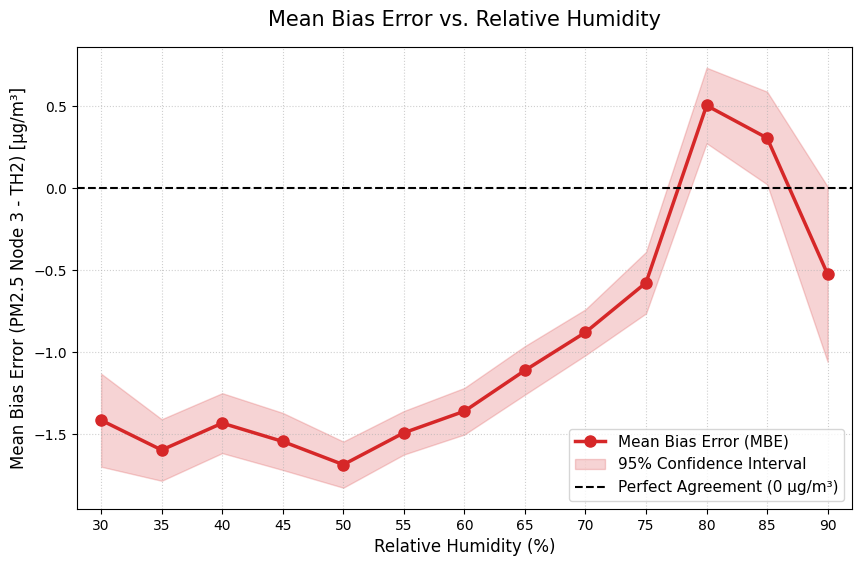

In [10]:
# 1. Bin by Relative Humidity (27.5% to 100% in 5% increments)     
bins = np.arange(27.5, 103, 5)
df_plot['RH_Bin_MBE'] = pd.cut(df_plot['node_3_humi'], bins=bins)
df_plot['RH_Bin_Mid'] = df_plot['RH_Bin_MBE'].apply(lambda x: x.mid if pd.notnull(x) else np.nan)

# 2. Calculate MBE and Standard Error for the Raw Error          
mbe_stats = df_plot.groupby('RH_Bin_Mid')['Raw_Error'].agg(['mean', 'sem', 'count']).reset_index()

# Drop bins with statistically insignificant samples (< 50 points)
mbe_stats = mbe_stats[mbe_stats['count'] > 50] 

# 3. Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Mean Bias Error line
ax.plot(mbe_stats['RH_Bin_Mid'], mbe_stats['mean'], marker='o', linestyle='-', color='#d62728', linewidth=2.5, markersize=8, label='Mean Bias Error (MBE)')

# Shade 95% Confidence Interval (1.96 * Standard Error)          
ax.fill_between(mbe_stats['RH_Bin_Mid'], 
                mbe_stats['mean'] - 1.96 * mbe_stats['sem'],     
                mbe_stats['mean'] + 1.96 * mbe_stats['sem'],     
                color='#d62728', alpha=0.2, label='95% Confidence Interval')

ax.axhline(0, color='black', linestyle='--', linewidth=1.5,      
label='Perfect Agreement (0 µg/m³)')

plt.title('Mean Bias Error vs. Relative Humidity', fontsize=15, pad=15)
plt.xlabel('Relative Humidity (%)', fontsize=12)
plt.ylabel('Mean Bias Error (PM2.5 Node 3 - TH2) [µg/m³]', fontsize=12)

# Set X-axis limits to start at 28%
plt.xticks(np.arange(30, 101, 5))
plt.xlim(28, 92)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)

os.makedirs('../data/06_outputs/phase1.3', exist_ok=True)        
plt.savefig('../data/06_outputs/phase1.3/mbe_decay.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Visualization: 1:1 Correlation Scatter Plot

Linear Agreement of Raw and Dried PM2.5 Observations against TH2 Reference. 1:1 correlation scatter plot comparing the Raw (uncalibrated) and
Dried (reference-free corrected) 1-hour PM2.5 sensor observations against the regulatory TH2 baseline. The solid diagonal represents perfect unity (y= x). Visualisation shows the pronounce "cone of error" above the baseline in the uncalibrated state, collapse towards the agreement line when calibrated, shifting the error trend towards 1:1 parity.

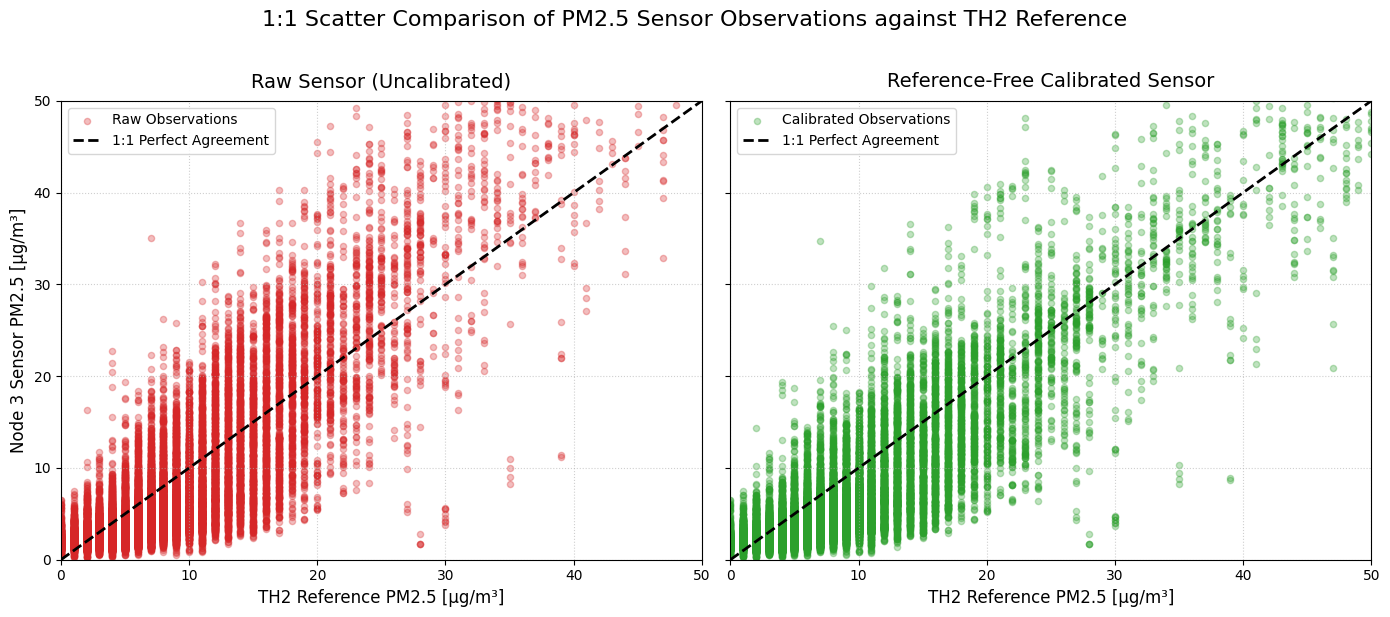

In [11]:
# Create 1x2 Subplots for a side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, sharex=True)

# Determine the absolute max to set standard axes
axis_lim = min(max(df_plot['th2_mer_pm25'].max(), df_plot['node_3_pm25'].max()) * 1.05, 50) 
x_vals = np.array([0, axis_lim])

# --- Plot 1: Raw Sensor ---
x_raw = df_plot['th2_mer_pm25']
y_raw = df_plot['node_3_pm25']

axes[0].scatter(x_raw, y_raw, color='#d62728', alpha=0.3, s=20, label='Raw Observations')
axes[0].plot(x_vals, x_vals, 'k--', linewidth=2, label='1:1 Perfect Agreement')

axes[0].set_title('Raw Sensor (Uncalibrated)', fontsize=14, pad=10)
axes[0].set_xlabel('TH2 Reference PM2.5 [µg/m³]', fontsize=12)
axes[0].set_ylabel('Node 3 Sensor PM2.5 [µg/m³]', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].set_xlim(0, axis_lim)
axes[0].set_ylim(0, axis_lim)
axes[0].legend(loc='upper left')

# --- Plot 2: Reference-Free Calibrated Sensor ---
x_cal = df_plot['th2_mer_pm25']
y_cal = df_plot['node_3_dry']

axes[1].scatter(x_cal, y_cal, color='#2ca02c', alpha=0.3, s=20, label='Calibrated Observations')              
axes[1].plot(x_vals, x_vals, 'k--', linewidth=2, label='1:1 Perfect Agreement')

axes[1].set_title('Reference-Free Calibrated Sensor', fontsize=14, pad=10)
axes[1].set_xlabel('TH2 Reference PM2.5 [µg/m³]', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].set_xlim(0, axis_lim)
axes[1].set_ylim(0, axis_lim)
axes[1].legend(loc='upper left')

# Main Title
plt.suptitle('1:1 Scatter Comparison of PM2.5 Sensor Observations against TH2 Reference', fontsize=16, y=1.02)
plt.tight_layout()

# Save the figure
os.makedirs('../data/06_outputs/phase1.3', exist_ok=True)        
plt.savefig('../data/06_outputs/phase1.3/correlation_scatter_1_to_1.png', dpi=300, bbox_inches='tight')       
plt.show()